In [1]:
import sys
import os
import torch
sys.path.append(os.path.abspath('../'))

from src.models.single_network import SingleNetwork
from src.models.mc_dropout import MCDropout
from src.models.deep_ensemble import DeepEnsemble
from src.training.trainer import ModelTrainer
from src.processing.preprocess import get_dataloaders_for_sipakmed, getdataframe_for_sipakmed
from src.processing.loading import load_image_folder
from src.utils.visualisation import plot_performance_curves, plot_metrics_performance, ReliabilityPlotter
import pandas as pd
import matplotlib.pyplot as plt


`{im_Dyskeratotic: 0, im_Koilocytic: 1, im_Metaplasticimage_path: 2, im_Parabasal:3, im_Superficial-Intermediate: 4}`

In [2]:
train_loader, val_loader, cal_loader, test_loader = get_dataloaders_for_sipakmed(batch_size=32, num_workers=4, model_type="resnet")


df_all = getdataframe_for_sipakmed(train_loader, val_loader, cal_loader, test_loader)
df_all

,subset,image_path,label
0,train,/home/conite/Documents/STAGE/HybridUncertainty...,1
1,train,/home/conite/Documents/STAGE/HybridUncertainty...,0
2,train,/home/conite/Documents/STAGE/HybridUncertainty...,4
3,train,/home/conite/Documents/STAGE/HybridUncertainty...,0
4,train,/home/conite/Documents/STAGE/HybridUncertainty...,4
...,...,...,...
4044,test,/home/conite/Documents/STAGE/HybridUncertainty...,2
4045,test,/home/conite/Documents/STAGE/HybridUncertainty...,4
4046,test,/home/conite/Documents/STAGE/HybridUncertainty...,2
4047,test,/home/conite/Documents/STAGE/HybridUncertainty...,3


In [3]:
single_net = SingleNetwork(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

mcdropout = MCDropout(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

deepensemble = DeepEnsemble(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789115370/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50

**1.0 Evaluation**

In [4]:
# single_net.train(epochs=50, model_path='single_net_resnet_sipakmed.pth')
single_net.load('../experiments/results/sipakmed/output_single_resnet50_sipakmed.pth')
results_sn = single_net.evaluate()
print(f"Accuracy: {results_sn['accuracy']} | F1: {results_sn['f1_score']} | Precision: {results_sn['precision']} | Recall: {results_sn['recall']} | Brier: {results_sn['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9720394736842105 | F1: 0.9720882585113793 | Precision: 0.9725019582066006 | Recall: 0.9720394736842105 | Brier: 0.044523559510707855 


In [5]:
mcdropout.load('../experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.pth')
results_mcd = mcdropout.evaluate()
print(f"Accuracy: {results_mcd['accuracy']} | F1: {results_mcd['f1_score']} | Precision: {results_mcd['precision']} | Recall: {results_mcd['recall']} | Brier: {results_mcd['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9720394736842105 | F1: 0.9720882585113793 | Precision: 0.9725019582066006 | Recall: 0.9720394736842105 | Brier: 0.044523559510707855 


In [6]:
deepensemble.load([
    f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.pth" for i in range(5)
])
results_de = deepensemble.evaluate()
print(f"Accuracy: {results_de['accuracy']} | F1: {results_de['f1_score']} | Precision: {results_de['precision']} | Recall: {results_de['recall']} | Brier: {results_de['brier_score']} ")


/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/deep_ensemble.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(model_path, map_location=

Model 1 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_0.pth
Model 2 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_1.pth
Model 3 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_2.pth
Model 4 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_3.pth
Model 5 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_4.pth

🔎 Predicting with ensemble member 1/5



🔎 Predicting with ensemble member 2/5



🔎 Predicting with ensemble member 3/5



🔎 Predicting with ensemble member 4/5



🔎 Predicting with ensemble member 5/5


Accuracy: 0.9917763157894737 | F1: 0.9917693469346797 | Precision: 0.9917760834820101 | Recall: 0.9917763157894737 | Brier: 0.017302077263593674 


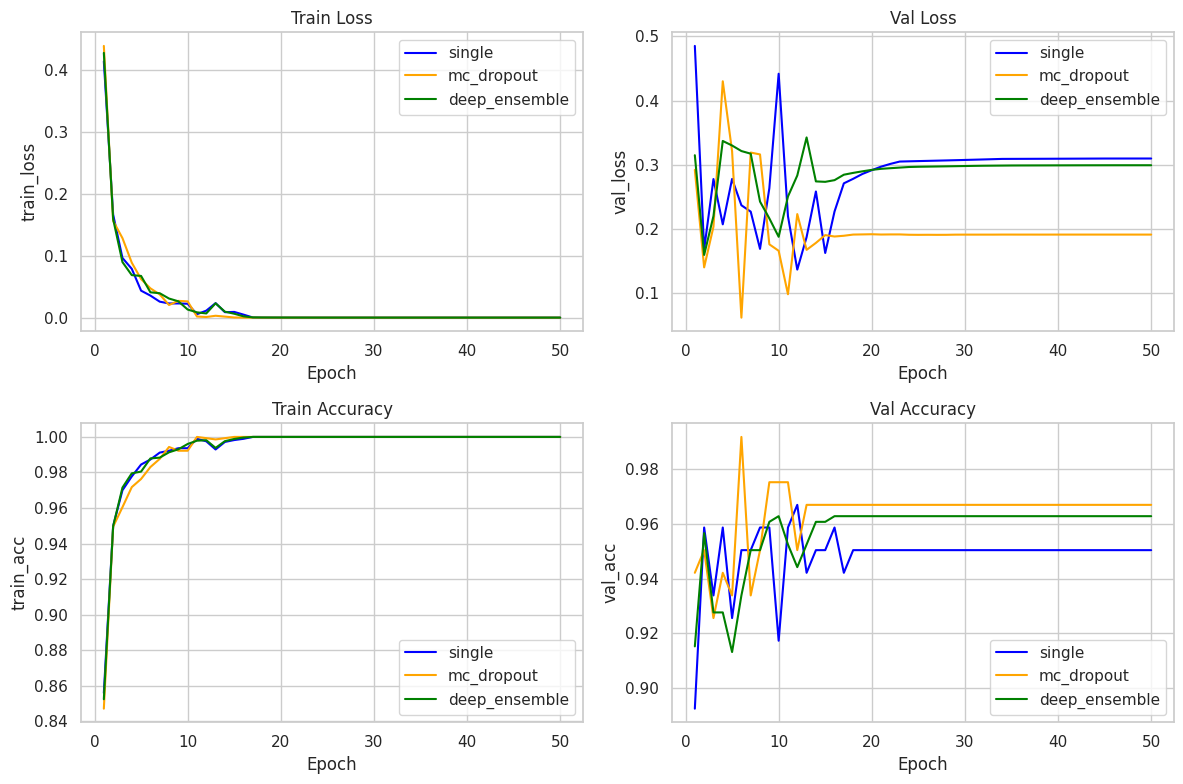

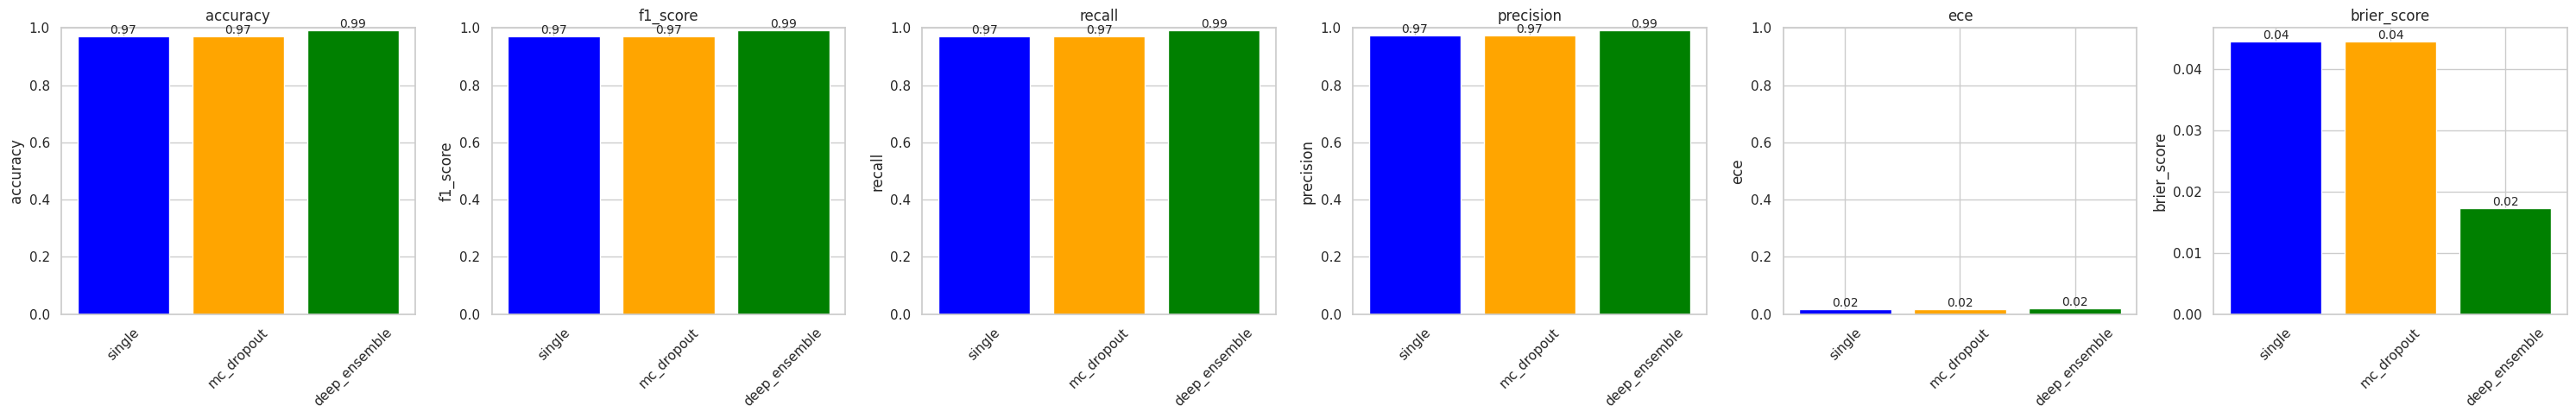

In [7]:
ENSEMBLE_SIZE = 5
path_results = {
    'single': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_single_resnet50_sipakmed.json"),
    
    'mc_dropout': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.json"),
    'deep_ensemble': [
        os.path.join(f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.json") 
        for i in range(1,ENSEMBLE_SIZE)
    ]
}

gather_results = {
    'single': results_sn,
    'mc_dropout': results_mcd,
    'deep_ensemble': results_de
}


plot_performance_curves(path_results=path_results)
plot_metrics_performance(gather_results)

**Step 2: Analyze each model's calibration performance (e.g., via ECE, Brier score), identifying which base approach is best calibrated across the three datasets**


Plotting reliability diagram for approach: single


<Figure size 600x500 with 0 Axes>

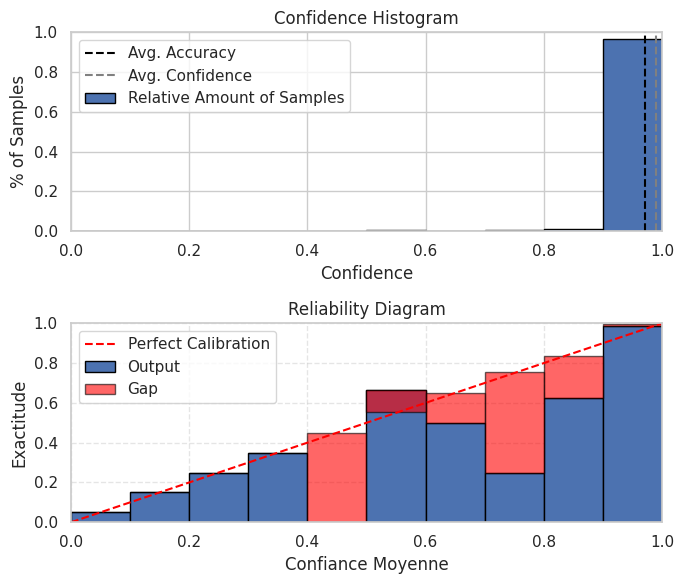

Plotting reliability diagram for approach: mc_dropout


<Figure size 600x500 with 0 Axes>

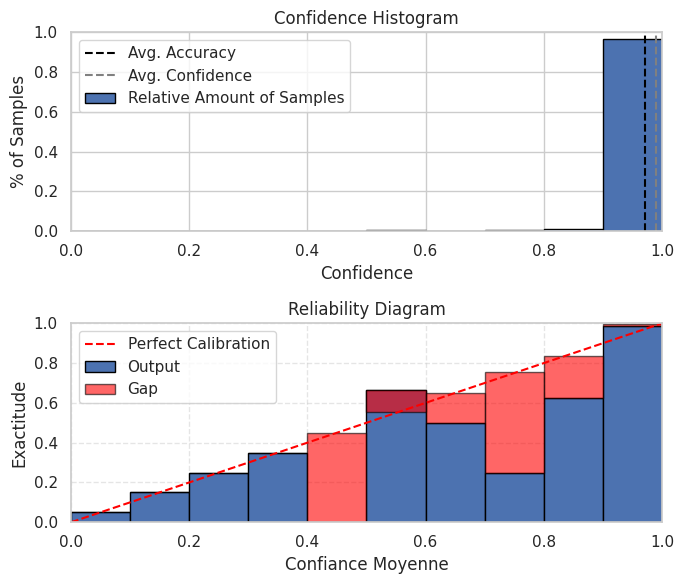

Plotting reliability diagram for approach: deep_ensemble


<Figure size 600x500 with 0 Axes>

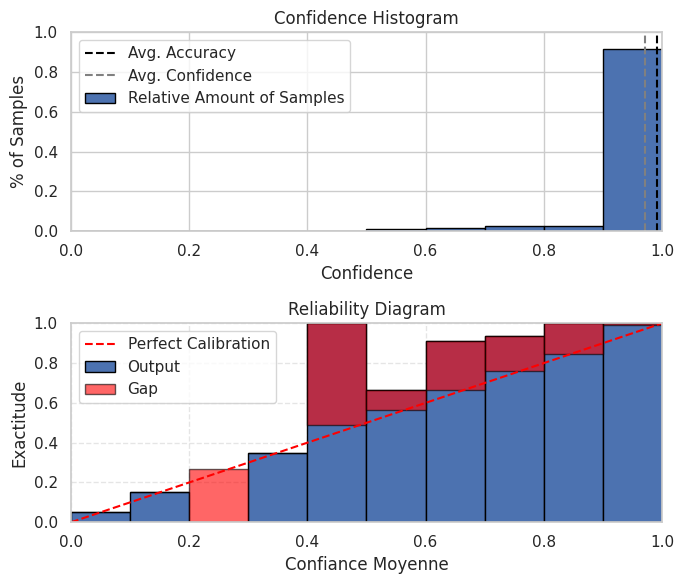

In [8]:
approaches_data = {
    'single': (results_sn['y_labels'], results_sn['y_probs']),
    'mc_dropout': (results_mcd['y_labels'], results_mcd['y_probs']),
    'deep_ensemble': (results_de['y_trues'], results_de['y_probs'])
}

plotter = ReliabilityPlotter(approaches_data)
plotter.plot_all_approaches(n_bins=10)

**Step 3: For each base method's (SingleNet, MCD, DE), apply APS, RAPS, and SAPS to create conformal sets, then compare their mean/median set sizes, marginal coverage, etc... and accuracy-per-set-size trade-offs to come out with the most efficient combinaison strategy on the three datasets.**

In [9]:
from src.conformal_prediction.aps import APS
from src.conformal_prediction.raps import RAPS
from src.conformal_prediction.gaps import GAPS
from src.conformal_prediction.geaps import GEAPS
from src.conformal_prediction.saps import SAPS
from src.conformal_prediction.eaps import EAPS


alpha = 0.05
predictors_sn = {
    'RAPS': RAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
    'APS': APS(alpha=alpha, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
    'GAPS': GAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
    'GEAPS': GEAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
    'SAPS': SAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
    'EAPS': EAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
}
predictors_mcd = {
    'RAPS': RAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
    'APS': APS(alpha=alpha, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
    'GAPS': GAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
    'GEAPS': GEAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
    'SAPS': SAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
    'EAPS': EAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
}
predictors_de = {
    'RAPS': RAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
    'APS': APS(alpha=alpha, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
    'GAPS': GAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
    'GEAPS': GEAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
    'SAPS': SAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
    'EAPS': EAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
}

# calibration and compute tau



In [10]:
# get number of correctly predicted and misclassified samples with probas=results_sn['y_probs'], labels=results_sn['y_labels']
import numpy as np

def get_correctly_predicted_and_misclassified_samples(probas, labels):
    correctly_predicted = []
    misclassified = []
    predicted_classes = np.argmax(probas, axis=1)  # Get predicted classes from probabilities
    for i in range(len(predicted_classes)):
        if predicted_classes[i] == labels[i]:
            correctly_predicted.append(i)
        else:
            misclassified.append(i)
    return correctly_predicted, misclassified

correctly_predicted_sn, misclassified_sn = get_correctly_predicted_and_misclassified_samples(results_sn['y_probs'], results_sn['y_labels'])
print(f"Single Net | Number of correctly predicted samples: {len(correctly_predicted_sn)}")
print(f"Single Net | Number of misclassified samples: {len(misclassified_sn)}")

correctly_predicted_mcd, misclassified_mcd = get_correctly_predicted_and_misclassified_samples(results_mcd['y_probs'], results_mcd['y_labels'])
print(f"MC Dropout | Number of correctly predicted samples: {len(correctly_predicted_mcd)}")
print(f"MC Dropout | Number of misclassified samples: {len(misclassified_mcd)}")

correctly_predicted_de, misclassified_de = get_correctly_predicted_and_misclassified_samples(results_de['y_probs'], results_de['y_trues'])
print(f"Deep Ensemble | Number of correctly predicted samples: {len(correctly_predicted_de)}")
print(f"Deep Ensemble | Number of misclassified samples: {len(misclassified_de)}")

Single Net | Number of correctly predicted samples: 591
Single Net | Number of misclassified samples: 17
MC Dropout | Number of correctly predicted samples: 591
MC Dropout | Number of misclassified samples: 17
Deep Ensemble | Number of correctly predicted samples: 603
Deep Ensemble | Number of misclassified samples: 5



=== Calibration avec alpha=0.05 ===

📌 Méthode : RAPS
  ➤ Tau (threshold): 0.9665

📌 Méthode : APS
  ➤ Tau (threshold): 0.9544

📌 Méthode : GAPS
  ➤ Tau (threshold): 0.9684

📌 Méthode : GEAPS
  ➤ Tau (threshold): 1.0000

📌 Méthode : SAPS
  ➤ Tau (threshold): 0.9753

📌 Méthode : EAPS
  ➤ Tau (threshold): 0.9554


/tmp/ipykernel_1201336/3325871294.py:7: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  predictor.calibrate()


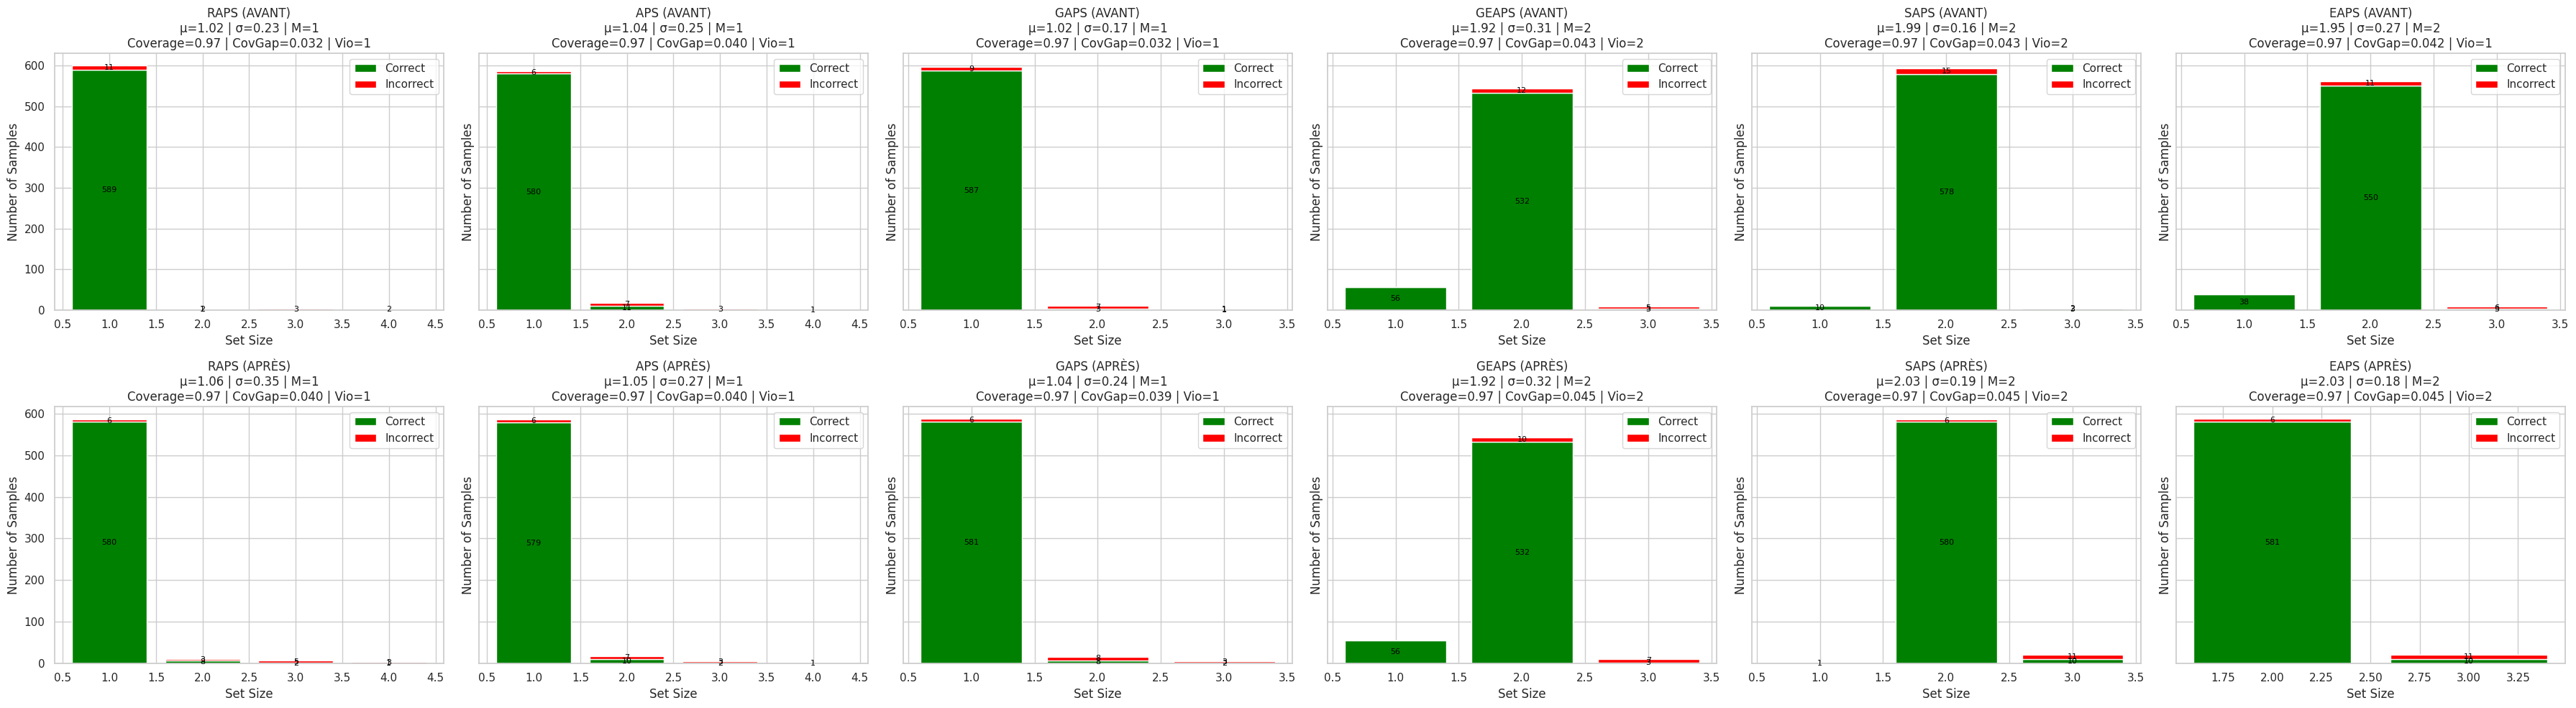


=== Calibration avec alpha=0.05 ===

📌 Méthode : RAPS
  ➤ Tau (threshold): 0.9597

📌 Méthode : APS
  ➤ Tau (threshold): 0.9526

📌 Méthode : GAPS
  ➤ Tau (threshold): 0.9734

📌 Méthode : GEAPS
  ➤ Tau (threshold): 1.0000

📌 Méthode : SAPS
  ➤ Tau (threshold): 0.9787

📌 Méthode : EAPS
  ➤ Tau (threshold): 0.9834


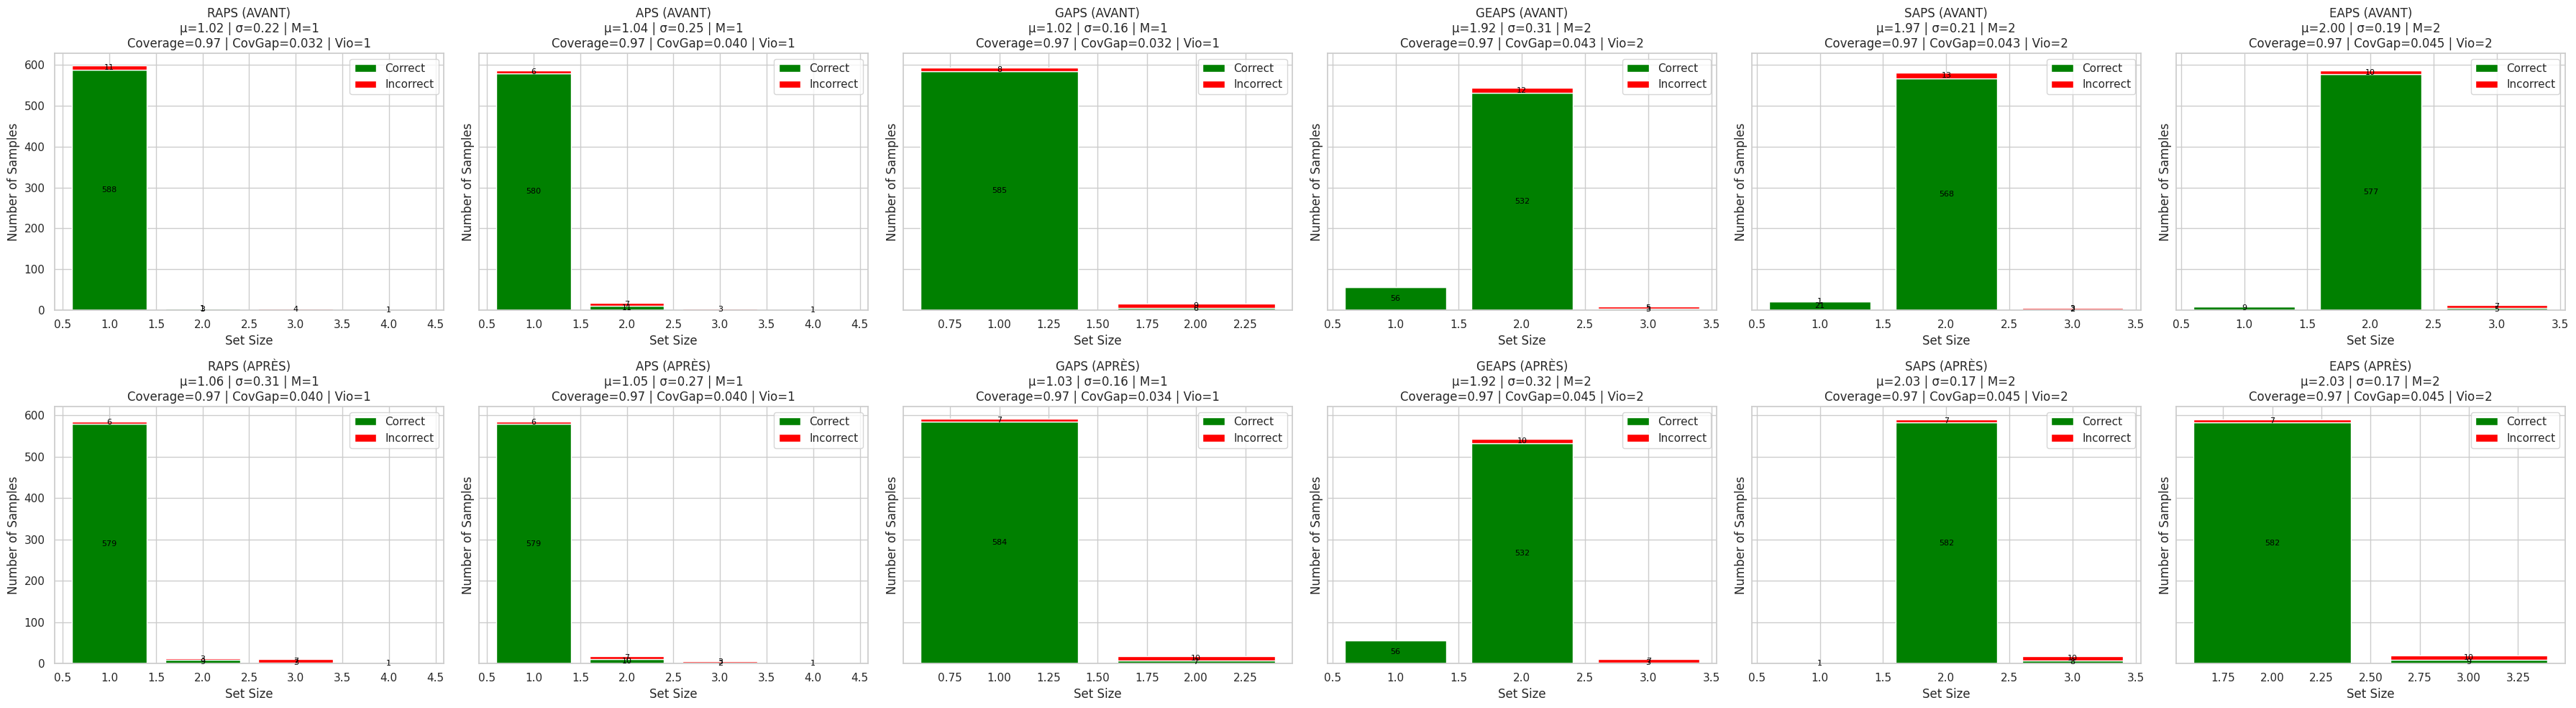


=== Calibration avec alpha=0.05 ===

📌 Méthode : RAPS
  ➤ Tau (threshold): 0.9449

📌 Méthode : APS
  ➤ Tau (threshold): 0.9408

📌 Méthode : GAPS
  ➤ Tau (threshold): 0.9452

📌 Méthode : GEAPS
  ➤ Tau (threshold): 1.0000

📌 Méthode : SAPS
  ➤ Tau (threshold): 0.9647

📌 Méthode : EAPS
  ➤ Tau (threshold): 0.9395


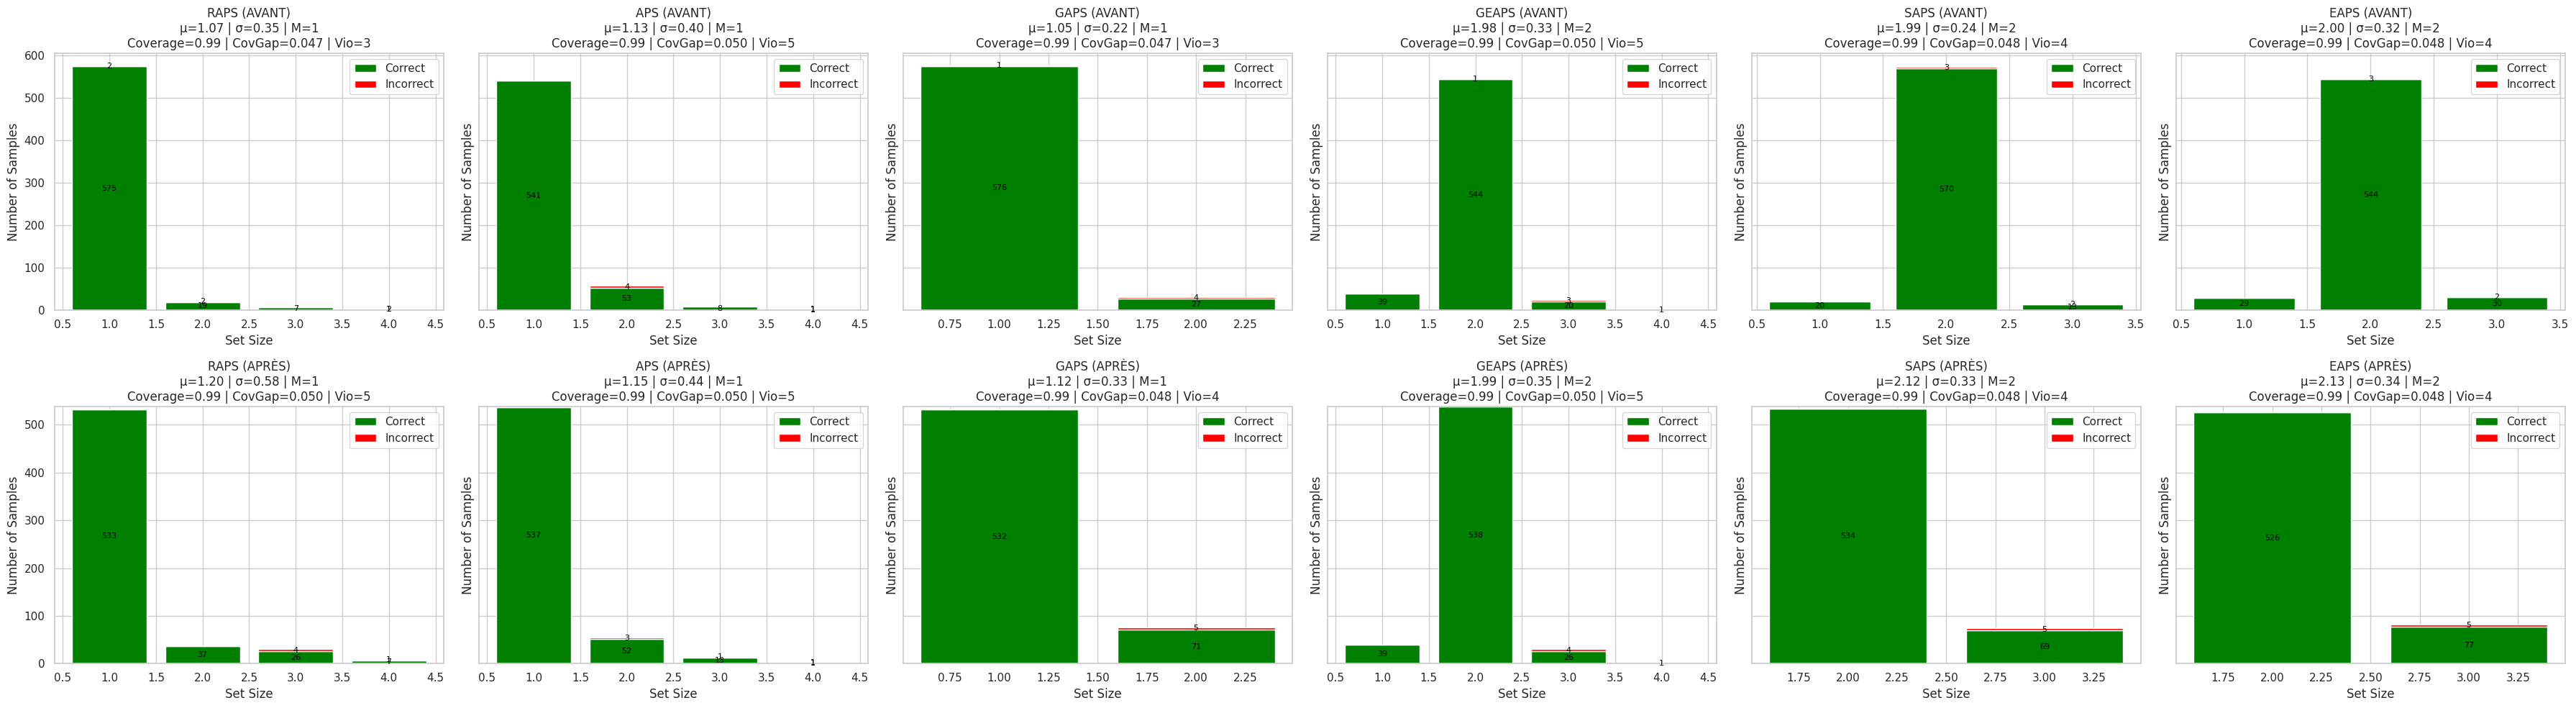

In [11]:
from src.utils.visualisation import plot_correct_incorrect_bars 

def calibrate_and_visualize(predictor_dict, test_probs, test_labels, test_vars, test_entropies, alpha):
    print(f"\n=== Calibration avec alpha={alpha} ===")
    for name, predictor in predictor_dict.items():
        print(f"\n📌 Méthode : {name}")
        predictor.calibrate()
        print(f"  ➤ Tau (threshold): {predictor.threshold:.4f}")
    
    plot_correct_incorrect_bars(
        predictor_dict=predictor_dict,
        test_probs=test_probs,
        y_test=test_labels,
        y_entropies=test_entropies,
        alpha=alpha
    )
# Pour Single Network
calibrate_and_visualize(
    predictor_dict=predictors_sn,
    test_probs=results_sn['y_probs'],
    test_labels=results_sn['y_labels'],
    test_vars=results_sn['y_variances'],
    test_entropies=results_sn['entropy'],
    alpha=0.05
)


# Pour MC Dropout
calibrate_and_visualize(
    predictor_dict=predictors_mcd,
    test_probs=results_mcd['y_probs'],
    test_labels=results_mcd['y_labels'],
    test_entropies=results_mcd['entropy'],
    test_vars=results_mcd['y_variances'],
    alpha=0.05
)

# Pour Deep Ensemble
calibrate_and_visualize(
    predictor_dict=predictors_de,
    test_probs=results_de['y_probs'],
    test_labels=results_de['y_trues'],
    test_entropies=results_de['entropy'],
    test_vars=results_mcd['y_variances'],
    alpha=0.05
)
